In [59]:
from datascience import *
import numpy as np

%matplotlib inline

import matplotlib.pyplot as plt

In [60]:
# Alamenda Country Jury Panels
jury = Table().with_columns(
    'Ethnicity', make_array('Asian', 'Black', 'Latino', 'White', 'Other'),
    'Eligible', make_array(0.15, 0.18, 0.12, 0.54, 0.01),
    'Panels', make_array(0.26, 0.08, 0.08, 0.54, 0.04)
)

jury

Ethnicity,Eligible,Panels
Asian,0.15,0.26
Black,0.18,0.08
Latino,0.12,0.08
White,0.54,0.54
Other,0.01,0.04


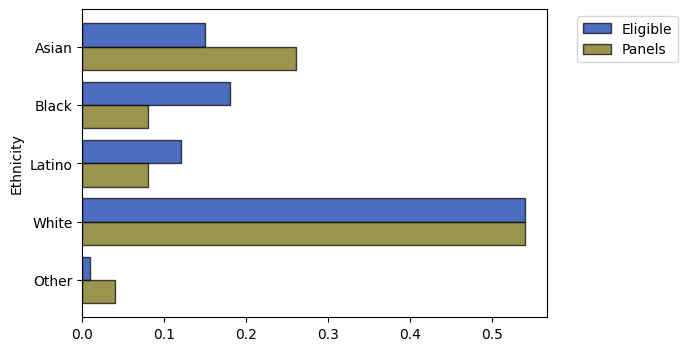

In [61]:
jury.barh("Ethnicity")

In [62]:
model = make_array(0.15, 0.18, 0.12, 0.54, 0.01)

In [63]:
simulated = sample_proportions(1423, model)
simulated

array([ 0.14546732,  0.18903725,  0.11524947,  0.53829937,  0.01194659])

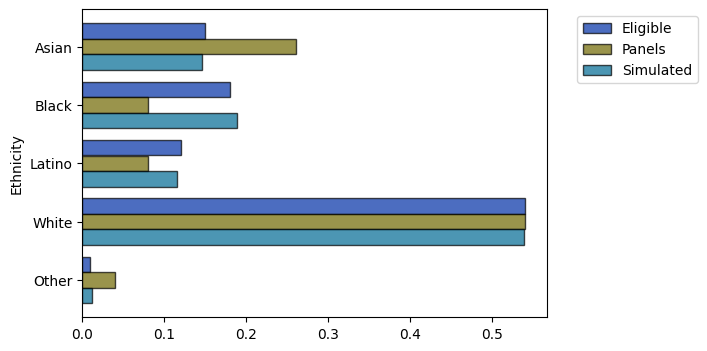

In [64]:
jury_with_simulated = jury.with_column("Simulated", simulated)
jury_with_simulated.barh("Ethnicity")

In [75]:
# diffs = np.abs(jury.column("Panels") - jury.column("Eligible"))
diffs = np.abs(jury.column("Panels") - model)

diffs

array([ 0.11,  0.1 ,  0.04,  0.  ,  0.03])

In [66]:
np.average(diffs)

0.056000000000000008

In [67]:
# Total Variation Distance
def tvd(dist1, dist2):
    return np.sum(np.abs(dist1 - dist2))/2

In [ ]:
tvd(jury.column("Panels"), model)

0.14000000000000001

In [70]:
def simulated_tvd():
    return tvd(sample_proportions(1423, model), model)

In [71]:
tvds = make_array()

for i in range(100000):
    new_tvd = simulated_tvd()
    tvds = np.append(tvds, new_tvd)

Observed TVD: 0.14


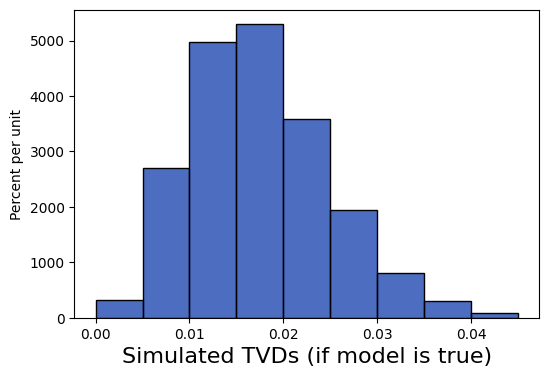

In [74]:
title = 'Simulated TVDs (if model is true)'
bins = np.arange(0, .05, .005)

Table().with_column(title, tvds).hist(bins = bins)
obsvd_tvd = tvd(jury.column("Panels"), model)
print('Observed TVD: ' + str(obsvd_tvd))
# observed_tvd = 